## Visaulizing Token-by-Token Inference in GPT models

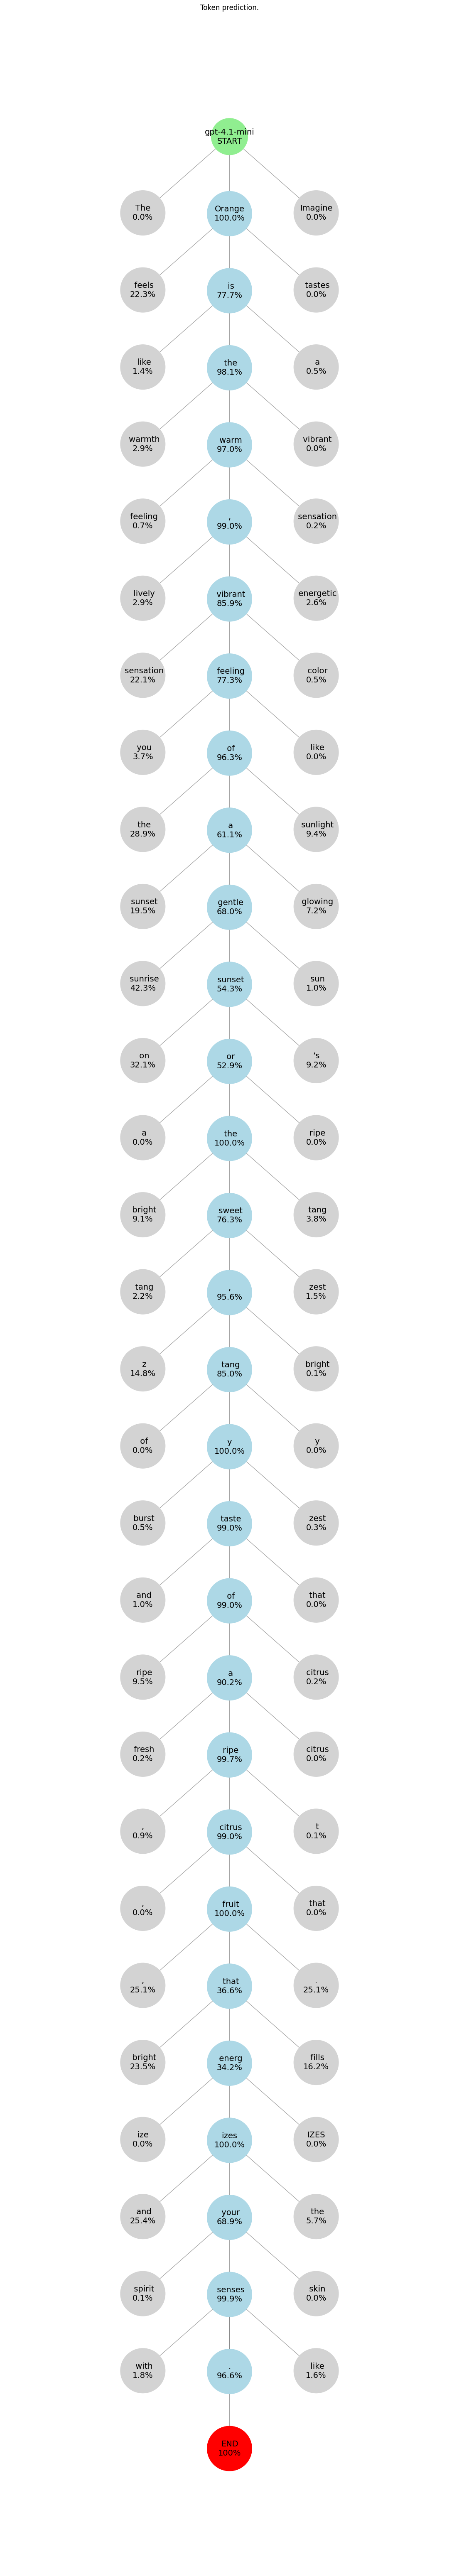

In [1]:
# from visualizer import TokenPredictor, create_token_graph, visualize_predictions
from visualizer import TokenPredictor, create_token_graph, visualize_predictions

message = "In one sentence, describe the color orange to someone who has never been able to see"
model_name = "gpt-4.1-mini"

predictor = TokenPredictor(model_name)
predictions = predictor.predict_tokens(message)
G = create_token_graph(model_name, predictions)
plt = visualize_predictions(G)
plt.show()

### Create Meeting Minute from an Audio files

In [2]:
# !pip install --upgrade bitsandbytes accelerate transformers==4.57.6

In [17]:
# libraries
from dotenv import load_dotenv
from huggingface_hub import login
import torch
from transformers import BitsAndBytesConfig, AutoTokenizer, AutoModelForCausalLM, TextStreamer
from IPython.display import display, Markdown, update_display
from openai import OpenAI
from google.colab import drive, userdata

In [4]:
HF_TOKEN='HF TOKEN'

load_dotenv(override=True)
# api_key = os.getenv('HF_TOKEN')

if not HF_TOKEN:
    print("API Keys not found")
else:
    print("API Key found and in use")

login(token=HF_TOKEN)
print('Login Successful')

API Key found and in use
Login Successful


In [12]:
drive.mount("/content/drive")
audio_filename = "/content/drive/MyDrive/denver_extract.mp3"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
LLAMA = 'meta-llama/Llama-3.2-1B-Instruct'

audio_file = open(audio_filename, 'rb')

#### STEP 1: Transcribe Audio

In [15]:
# OPTION 1: USE OPEN SOURCE FOR TRANSCRIPTION - HUGGING FACE PIPELINES

from transformers import pipeline

pipe = pipeline(
    'automatic-speech-recognition', 
    model='openai/whisper-medium.en', 
    dtype=torch.float16,
    device='cuda',
    return_timestamps=True

)

result = pipe(audio_filename)
transcription = result['text']

print(transcription)

Device set to use cuda


 kind of the confluence of this whole idea of a Confluence Week, the merging of two rivers, and as we've kind of seen recently in politics and in the world, there's a lot of situations where water is very important right now, and it's a very big issue. So that is the reason that the back of the logo is considered water. So I'll let you see the creation of the logo here. Yeah, so that basically kind of sums up the reason behind the logo and all the meanings behind the symbolism. And you'll hear a little bit more about our Confluence Week is basically highlighting all of these indigenous events and things that are happening around Denver so that we can kind of bring more people together and kind of share this whole idea of Indigenous Peoples Day. So, thank you. Thank you so much and thanks for your leadership. All right, welcome to the Denver City Council meeting of Monday, October 9th. Please rise with the Pledge of Allegiance by Councilman Lopez. I pledge allegiance to the flag of the 

In [16]:
open_source_transcription = transcription

In [19]:
# OPTION 2: USE OPENAI FOR TRANSCRIPTION
AUDIO_MODEL = 'gpt-4o-mini-transcribe'

openai_api_key = 'OPENAI API KEY'
openai = OpenAI(api_key=openai_api_key)
transcription = openai.audio.transcriptions.create(model=AUDIO_MODEL, file=audio_file, response_format='text')

print(transcription)

And kind of the confluence of this whole idea of the Confluence Week, the merging of two rivers, and as we've kind of seen recently in politics and in the world, there's a lot of situations where water is very important right now and is a very big issue, so that is the reason that the back of the logo is considered water. So I'll let you see the creation of the logo here. And yes, so that basically kind of sums up the reason behind the logo and all the meanings behind the symbolism. And you'll hear a little bit more about our Confluence Week is basically highlighting all of these indigenous events and things that are happening around Denver so that we can kind of bring more people together and kind of share this whole idea of Indigenous Peoples Day. So thank you. Thank you so much, and thanks for your leadership. All right. Welcome to the Denver City Council meeting of Monday, October 9th. Please rise with the Pledge of Allegiance by Councilman Lopez. I pledge allegiance to the flag of

#### STEP 2: Analyze & Report

In [20]:
system_message = """
You produce minutes of meetings from transcripts, with summary, key discussion points,
takeaways and action items with owners, in markdown format without code blocks.
"""

user_prompt = f"""
Below is an extract transcript of a Denver council meeting.
Please write minutes in markdown without code blocks, including:
- a summary with attendees, location and date
- discussion points
- takeaways
- action items with owners

Transcription:
{transcription}
"""

messages = [
    {"role": "system", "content": system_message},
    {"role": "user", "content": user_prompt}
]

In [21]:
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type='nf4'
)

In [22]:
tokenizer = AutoTokenizer.from_pretrained(LLAMA)
tokenizer.pad_token = tokenizer.eos_token

inputs = tokenizer.apply_chat_template(messages, return_tensors='pt').to('cuda')

streamer = TextStreamer(tokenizer=tokenizer)
model = AutoModelForCausalLM.from_pretrained(LLAMA, device_map='auto', quantization_config=quant_config)

outputs = model.generate(inputs, max_new_tokens=2000, streamer=streamer)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 15 Sep 2026

You produce minutes of meetings from transcripts, with summary, key discussion points,
takeaways and action items with owners, in markdown format without code blocks.<|eot_id|><|start_header_id|>user<|end_header_id|>

Below is an extract transcript of a Denver council meeting.
Please write minutes in markdown without code blocks, including:
- a summary with attendees, location and date
- discussion points
- takeaways
- action items with owners

Transcription:
And kind of the confluence of this whole idea of the Confluence Week, the merging of two rivers, and as we've kind of seen recently in politics and in the world, there's a lot of situations where water is very important right now and is a very big issue, so that is the reason that the back of the logo is considered water. So I'll let you see the creation of the logo here. And yes, so that basically kind of su

In [24]:
response = tokenizer.decode(outputs[0])

In [25]:
display(Markdown(response))

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 15 Sep 2026

You produce minutes of meetings from transcripts, with summary, key discussion points,
takeaways and action items with owners, in markdown format without code blocks.<|eot_id|><|start_header_id|>user<|end_header_id|>

Below is an extract transcript of a Denver council meeting.
Please write minutes in markdown without code blocks, including:
- a summary with attendees, location and date
- discussion points
- takeaways
- action items with owners

Transcription:
And kind of the confluence of this whole idea of the Confluence Week, the merging of two rivers, and as we've kind of seen recently in politics and in the world, there's a lot of situations where water is very important right now and is a very big issue, so that is the reason that the back of the logo is considered water. So I'll let you see the creation of the logo here. And yes, so that basically kind of sums up the reason behind the logo and all the meanings behind the symbolism. And you'll hear a little bit more about our Confluence Week is basically highlighting all of these indigenous events and things that are happening around Denver so that we can kind of bring more people together and kind of share this whole idea of Indigenous Peoples Day. So thank you. Thank you so much, and thanks for your leadership. All right. Welcome to the Denver City Council meeting of Monday, October 9th. Please rise with the Pledge of Allegiance by Councilman Lopez. I pledge allegiance to the flag of the United States of America and to the republic for which it stands, one nation, under God, indivisible, with liberty and justice for all. All right, thank you, Councilman Lopez. Madam Secretary, roll call. Black? Here. Espinoza? Here. Flynn? Gilmore? Here. Cashman? Here. Kanich? Here. Lopez? Here. New? Here. Ortega? Here. Sussman? Here. Mr. President? Here. 11 present. 11 members present. We do have a quorum. Approval of the minutes. Are there any corrections to the minutes of October 2nd? Seeing none, minutes of October 2nd stand approved. Council announcements. Are there any announcements by members of Council? Councilman Clark. Thank you, Mr. President. I just wanted to invite everyone down to the first ever Halloween parade on Broadway in Lucky District 7. It will happen on Saturday, October 21st at 6 o'clock p.m. It will move along Broadway from 3rd to Alameda. It's going to be a fun, family-friendly event. Everyone is invited to come down, wear a costume. There will be candy for the kids and there are tiki zombies and 29 hearses and all kinds of fun and funky stuff on the fun and funky part of Broadway. So please join us October 21st at 6 o'clock for the Broadway Halloween parade. Thank you, Mr. President. All right. Thank you, Councilman Clark. I will be there. All right. Presentations. Madam Secretary, do we have any presentations? None, Mr. President. Communications. Do we have any communications? None, Mr. President. We do have one proclamation this evening. Proclamation 1127 in observance of the annual Indigenous Peoples Day in the City and County of Denver. Councilman Lopez, will you please read it? Thank you, Mr. President. Proclamation number 17. Well, let me just say this differently. Proclamation number 1127 series of 2017 in observance of the second annual Indigenous Peoples Day in the City and County of Denver. Whereas the Council of the City and County of Denver recognizes that the indigenous peoples have lived and flourished on the lands known as the Americas since time immemorial and that Denver and the surrounding communities are built upon the ancestral homelands of numerous indigenous tribes, which include the Southern Ute, the Ute Mountain Ute tribes of Colorado. And whereas the tribal homelands and seasonal encampments of the Arapaho and Cheyenne people along the banks of the Cherry Creek and South Platte River confluence gave bearing to the future settlements that would become the birthplace of the Mile High City. And whereas Colorado encompasses the ancestral homelands of 48 tribes and the City and County of Denver and surrounding communities are home to the descendants of approximately 100 tribal nations. And whereas on October 3rd, 2016, the City and County of Denver unanimously passed Council Bill 801 series of 2016 officially designating the second Monday of October of each year as Indigenous Peoples Day in Denver, Colorado. And whereas the Council of the City and County of Denver continues to recognize and value the vast contributions made to the community through indigenous peoples knowledge, science, philosophy, arts and culture. And through these contributions, the City of Denver has developed and thrived. Whereas the indigenous community, especially youth, have made great efforts this year to draw attention to the contributions of indigenous people, including Confluence Week, drawing record attendance to a national indigenous youth leadership conference, leading conversations on inclusion with their peers and supporting increased indigenous youth participation in science and engineering. Now, therefore, be it proclaimed by the Council of the City and County of Denver, section one, that the Council of the City and County of Denver celebrates and honors the cultural and foundational contributions of indigenous people to our history, our past, our present and future and continues to promote the education of the Denver community about these historical and contemporary contributions of indigenous people. Section two, that the City and County of Denver, Colorado does hereby observe October 9th, 2017 as Indigenous Peoples Day. Section three, that the clerk of the City and County of Denver shall attest and affix the seal of the City and County of Denver to this proclamation and that a copy be transmitted to the Denver American Indian Commission, the City and County of Denver School District Number One and the Colorado Commission on Indian Affairs. Thank you, Councilman Lopez. Your motion to adopt. Mr. President, I move that proclamation number 1127 series of 2017 be adopted. All right, it has been moved and seconded. Council members of Council. Councilman Lopez. Thank you, Mr. President. It gives me a lot of pleasure and pride to read this proclamation officially for the third time, but as Indigenous Peoples Day in Denver officially for the second time. It is, it's always awesome to be able to see not just this proclamation come through, come by my desk, but to see the so many different people from our community in our, in our council chambers. It was a very beautiful piece of artwork that you presented to us earlier, and it is exactly the spirit that we drafted this proclamation and this actual, the ordinance that created Indigenous Peoples Day when we sat down and wrote it, and as a community, we couldn't think of anything else to begin except for the confluence of the two rivers. And those confluences of the two rivers created such a great city. And we live in such an amazing city and we, we're all proud of it. And sometimes we, and a lot of people from all over the country are proud of, all over the world are proud of it. And sometimes a little too proud of it, just tell them to go back home. But I'm kidding when I say that. But the, the, the really nice thing about this is that we are celebrating Indigenous Peoples Day out of pride for who we are and who we are as a city and the contributions of indigenous people to the city, not out of spite, not out of a replacement of one culture over the other, or out of contempt or disrespect. You know, I think of a, a quote that Cesar Chavez made very, very popular. And it stuck with me for a very long time. And anytime I have the opportunity, I speak in front of children, and especially children in our community that, you know, they, they often second guess themselves on where they're coming from, who they are. And I always say that, you know, it's, it's very important to be proud of who you're from. And the quote that I use from Cesar Chavez is, you know, pride in one's own culture does not require contempt or disrespect of another. Right? And that's very important. It's very important for us to recognize that no matter who we are, where we come from in this society, that your pride in your own culture doesn't require, should not require the contempt or disrespect of another. And man, what a year to be, for that to just sit on our shoulders for a while, for us to think about. Right? And so I wanted to, just to thank you all, to thank the commission. There's going to be a couple individuals that are going to come speak. Thank you for your art, your lovely artwork for us to see what's in your heart and what now has become a, probably is going to be a very important symbol for the community. And also just for the work, the daily work every single day. We still have a lot of brothers and sisters whose ancestors once lived in these lands freely now stand on street corners. Right? In poverty. Without access to services. Right? Without access to, to sobriety or even housing or jobs. And what a, what a cruel way to pay back a culture that has paved the way for the city to be built upon its shores. Right? So we have a lot of work to do. And these kind of proclamations and this day is not a day off, it's a day on in Denver. Right? In, in addressing those, those critical issues. So I, I know that my colleagues are very supportive. I'm going to ask you to support this proclamation, as I know you always have done in the past. I'm very proud of today. Oh, and we made Time Magazine and Newsweek once again today as being a leader in terms of the cities that are celebrating Indigenous Peoples Day. I wanted to make a point out of that. Thank you, Councilman Lopez. And thank you for sponsoring this. Councilwoman Ortega. Mr. President, I want to ask that my name be added. I don't think I could add much more to what Councilman Lopez has shared with us. I want to thank him for bringing this forward and really just appreciate all the contributions that our Native American community has contributed to this great city and great state. I worked in the Lieutenant Governor's office when the<|eot_id|><|start_header_id|>assistant<|end_header_id|>

**Summary**

The Denver City Council meeting was held on Monday, October 9th. The council members discussed the concept of Confluence Week, a celebration of the confluence of two rivers that gave birth to the city of Denver. They also recognized the importance of Indigenous Peoples Day, which was first proposed in 2016. The council passed a proclamation declaring October 9th as Indigenous Peoples Day.

**Discussion Points**

* The council discussed the concept of Confluence Week and its significance in recognizing the confluence of two rivers that gave birth to the city of Denver.
* They also discussed the importance of Indigenous Peoples Day and its significance in celebrating the contributions of indigenous people to the city and state.
* The council recognized the contributions of indigenous people to the city and state, including the creation of the logo for the city and the development of the city.

**Takeaways**

* The council passed a proclamation declaring October 9th as Indigenous Peoples Day.
* The council recognized the importance of Indigenous Peoples Day and its significance in celebrating the contributions of indigenous people to the city and state.
* The council also recognized the contributions of indigenous people to the city and state, including the creation of the logo for the city and the development of the city.

**Action Items**

* Councilman Lopez:
  - Read the proclamation and make it official for the third time.
  - Present the artwork that was presented to the council earlier in the meeting.
  - Thank the commission for their support.
* Councilwoman Ortega:
  - Add Councilman Lopez's name to the list of supporters for the proclamation.

**Next Steps**

* The council will review the proclamation and make any necessary changes.
* The council will also review the artwork presented to them earlier in the meeting and make any necessary decisions.<|eot_id|>